# Global Wheat Head Split Quality Check

This notebook checks whether the train/validation/test split is scientifically reasonable.

It answers:
- Is the split ratio close to a standard setup (roughly 80/10/10)?
- Are validation and test sets distributed similarly to training?
- Is there potential split bias by domain composition?

Main checks:
1. Image count ratio by split
2. Object count per image distribution (KS test)
3. Bounding-box area distribution (KS test)
4. Domain composition by split (chi-square test)
5. Final PASS/WARN summary

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path('/home/khanh/Projects/DifficultyAgri')
YOLO_ROOT = PROJECT_ROOT / 'datasets/global_wheat_head/yolo_format/global_wheat_head_yolo'
RAW_ROOT = PROJECT_ROOT / 'datasets/global_wheat_head/raw'

SPLITS = ['train', 'val', 'test']

print(f'YOLO root exists: {YOLO_ROOT.exists()}')
print(f'RAW root exists:  {RAW_ROOT.exists()}')

YOLO root exists: True
RAW root exists:  True


## Load Split Metadata and Labels

In [2]:
def read_yolo_label_file(label_path: Path):
    rows = []
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            x_c, y_c, w, h = map(float, parts[1:5])
            rows.append((cls, x_c, y_c, w, h))
    return rows

split_rows = []
object_rows = []

for split in SPLITS:
    images_dir = YOLO_ROOT / split / 'images'
    labels_dir = YOLO_ROOT / split / 'labels'

    image_files = sorted(list(images_dir.glob('*.png')) + list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.jpeg')))
    label_files = sorted(labels_dir.glob('*.txt'))

    split_rows.append({
        'split': split,
        'n_images': len(image_files),
        'n_labels': len(label_files),
        'images_dir': str(images_dir),
        'labels_dir': str(labels_dir),
    })

    for label_file in label_files:
        image_name = label_file.stem + '.png'
        boxes = read_yolo_label_file(label_file)

        split_rows.append({
            'split': split,
            'image_name': image_name,
            'n_objects': len(boxes),
            'type': 'image_level'
        })

        for cls, x_c, y_c, w, h in boxes:
            object_rows.append({
                'split': split,
                'image_name': image_name,
                'class_id': cls,
                'width': w,
                'height': h,
                'box_area_norm': w * h,
                'aspect_ratio': (w / h) if h > 0 else np.nan,
            })

split_overview_df = pd.DataFrame([r for r in split_rows if 'type' not in r])
image_level_df = pd.DataFrame([r for r in split_rows if r.get('type') == 'image_level'])
object_df = pd.DataFrame(object_rows)

display(split_overview_df)
print(f'Total image-level rows: {len(image_level_df):,}')
print(f'Total object rows: {len(object_df):,}')

,split,n_images,n_labels,images_dir,labels_dir
0,train,2700,2700,/home/khanh/Projects/DifficultyAgri/datasets/g...,/home/khanh/Projects/DifficultyAgri/datasets/g...
1,val,337,337,/home/khanh/Projects/DifficultyAgri/datasets/g...,/home/khanh/Projects/DifficultyAgri/datasets/g...
2,test,339,339,/home/khanh/Projects/DifficultyAgri/datasets/g...,/home/khanh/Projects/DifficultyAgri/datasets/g...


Total image-level rows: 3,376
Total object rows: 145,411


## 1) Split Ratio Check (Standard 80/10/10)

,split,n_images,ratio,expected_ratio,abs_diff,within_3pct_tolerance
0,train,2700,0.799763,0.8,0.000237,True
1,val,337,0.099822,0.1,0.000178,True
2,test,339,0.100415,0.1,0.000415,True


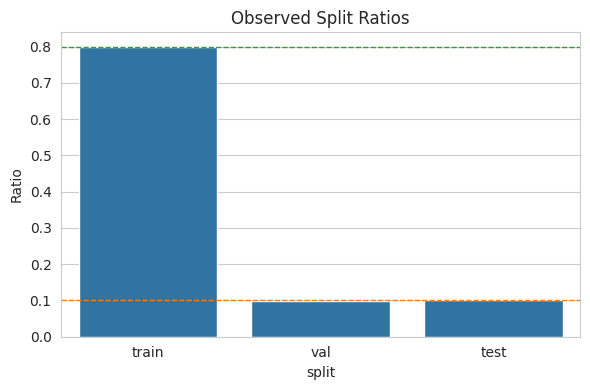

In [3]:
ratio_df = split_overview_df[['split', 'n_images']].copy()
total_images = ratio_df['n_images'].sum()
ratio_df['ratio'] = ratio_df['n_images'] / total_images

expected = {'train': 0.80, 'val': 0.10, 'test': 0.10}
ratio_df['expected_ratio'] = ratio_df['split'].map(expected)
ratio_df['abs_diff'] = (ratio_df['ratio'] - ratio_df['expected_ratio']).abs()
ratio_df['within_3pct_tolerance'] = ratio_df['abs_diff'] <= 0.03

display(ratio_df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=ratio_df, x='split', y='ratio', ax=ax)
ax.axhline(0.8, color='tab:green', linestyle='--', linewidth=1)
ax.axhline(0.1, color='tab:orange', linestyle='--', linewidth=1)
ax.set_title('Observed Split Ratios')
ax.set_ylabel('Ratio')
plt.tight_layout()
plt.show()

## 2) Distribution Similarity: Objects per Image and Box Area

Scientific expectation: validation and test should look like train in core data distribution.

,metric,comparison,ks_stat,p_value,similar_at_alpha_0_05
0,n_objects,train vs val,0.047216,4.998014e-01,True
1,n_objects,train vs test,0.042222,6.387487e-01,True
2,box_area_norm,train vs val,0.031248,1.903092e-11,False
3,box_area_norm,train vs test,0.033558,1.946761e-13,False


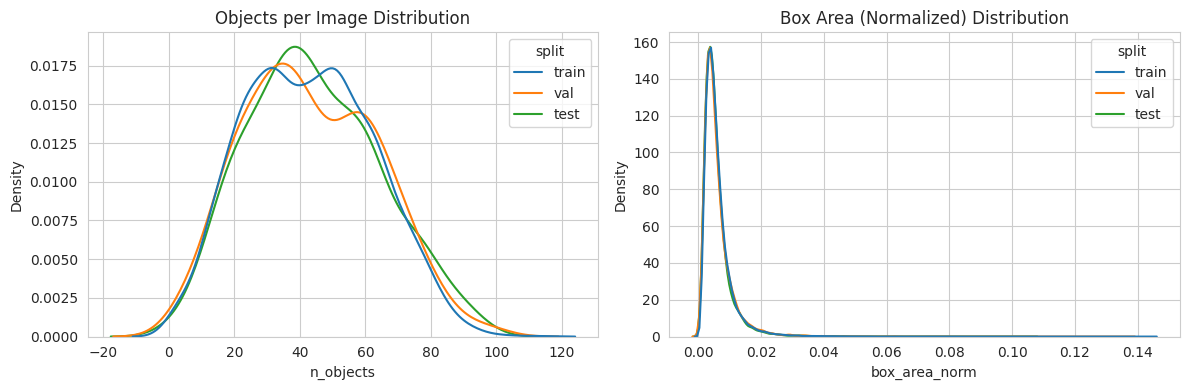

In [4]:
def ks_compare(df, value_col, ref_split='train', other_splits=('val', 'test')):
    rows = []
    ref = df.loc[df['split'] == ref_split, value_col].dropna().values
    for sp in other_splits:
        cur = df.loc[df['split'] == sp, value_col].dropna().values
        stat, p = ks_2samp(ref, cur)
        rows.append({
            'metric': value_col,
            'comparison': f'{ref_split} vs {sp}',
            'ks_stat': stat,
            'p_value': p,
            'similar_at_alpha_0_05': p >= 0.05,
        })
    return pd.DataFrame(rows)

ks_objects = ks_compare(image_level_df, 'n_objects')
ks_area = ks_compare(object_df, 'box_area_norm')
ks_results = pd.concat([ks_objects, ks_area], ignore_index=True)

display(ks_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=image_level_df, x='n_objects', hue='split', common_norm=False, ax=axes[0])
axes[0].set_title('Objects per Image Distribution')

sns.kdeplot(data=object_df, x='box_area_norm', hue='split', common_norm=False, ax=axes[1])
axes[1].set_title('Box Area (Normalized) Distribution')
plt.tight_layout()
plt.show()

## 3) Domain Composition Balance Across Splits

If domain composition differs strongly across splits, evaluation can be biased.

Domain contingency table:


domain,arvalis_1,arvalis_2,arvalis_3,ethz_1,inrae_1,rres_1,usask_1
split,,,,,,,
test,113,24,46,74,17,41,24
train,827,162,457,592,146,363,153
val,115,18,59,81,13,28,23


Chi-square p-value for split-domain independence: 0.260531


<Figure size 1200x400 with 0 Axes>

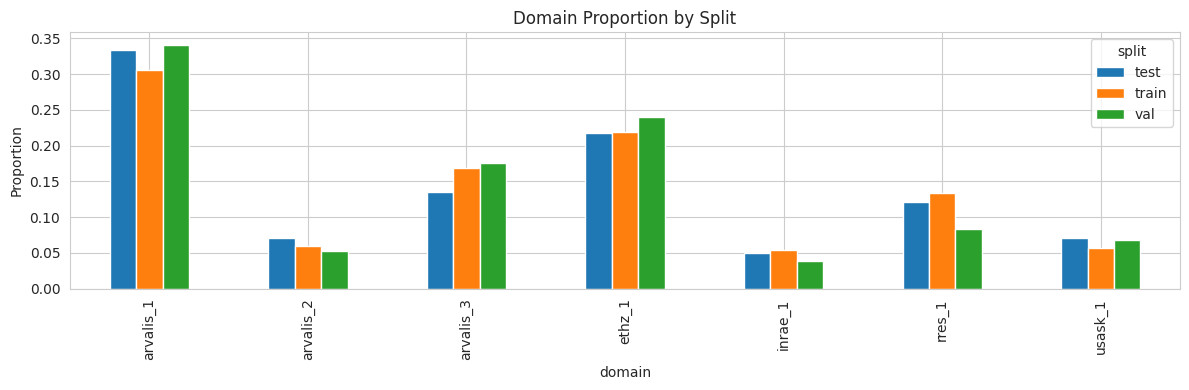

In [5]:
# Build image_name -> domain from raw folders
raw_map_rows = []
for domain_dir in sorted([p for p in RAW_ROOT.iterdir() if p.is_dir()]):
    if domain_dir.name == 'labels_extracted':
        continue
    for img in list(domain_dir.glob('*.png')) + list(domain_dir.glob('*.jpg')) + list(domain_dir.glob('*.jpeg')):
        raw_map_rows.append({'image_name': img.name, 'domain': domain_dir.name})
raw_map_df = pd.DataFrame(raw_map_rows).drop_duplicates(subset=['image_name'])

# Build image list by split from YOLO images folder
split_image_rows = []
for split in SPLITS:
    images_dir = YOLO_ROOT / split / 'images'
    for img in list(images_dir.glob('*.png')) + list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.jpeg')):
        split_image_rows.append({'split': split, 'image_name': img.name})
split_images_df = pd.DataFrame(split_image_rows)

split_domain_df = split_images_df.merge(raw_map_df, on='image_name', how='left')

contingency = pd.crosstab(split_domain_df['split'], split_domain_df['domain'])
chi2, p_value_domain, dof, expected = chi2_contingency(contingency)

print('Domain contingency table:')
display(contingency)
print(f'Chi-square p-value for split-domain independence: {p_value_domain:.6g}')

plt.figure(figsize=(12, 4))
prop_table = contingency.div(contingency.sum(axis=1), axis=0)
prop_table.T.plot(kind='bar', figsize=(12, 4))
plt.title('Domain Proportion by Split')
plt.ylabel('Proportion')
plt.legend(title='split')
plt.tight_layout()
plt.show()

## 4) Final Scientific Split Verdict

In [6]:
checks = []

# Check A: split ratios close to 80/10/10 within ±3%
ratio_ok = bool(ratio_df['within_3pct_tolerance'].all())
checks.append({'check': 'Split ratio close to 80/10/10 (±3%)', 'pass': ratio_ok})

# Check B: object-count and area distributions similar between train and val/test
ks_ok = bool(ks_results['similar_at_alpha_0_05'].all())
checks.append({'check': 'Train vs val/test distribution similarity (KS p>=0.05)', 'pass': ks_ok})

# Check C: domain composition not significantly different across splits
domain_ok = bool(p_value_domain >= 0.05)
checks.append({'check': 'Domain composition balance (chi-square p>=0.05)', 'pass': domain_ok})

verdict_df = pd.DataFrame(checks)
scientific_verdict = 'PASS' if verdict_df['pass'].all() else 'WARN'

display(verdict_df)
print(f'Final Verdict: {scientific_verdict}')

if scientific_verdict == 'PASS':
    print('Interpretation: Split looks scientifically reasonable for standard evaluation.')
else:
    print('Interpretation: Potential split bias detected. Review failed checks above.')

# Optional export
report_path = PROJECT_ROOT / 'notebooks' / 'global_wheat_head_split_quality_report.csv'
verdict_df.to_csv(report_path, index=False)
print(f'Report saved to: {report_path}')

,check,pass
0,Split ratio close to 80/10/10 (±3%),True
1,Train vs val/test distribution similarity (KS ...,False
2,Domain composition balance (chi-square p>=0.05),True


Final Verdict: WARN
Interpretation: Potential split bias detected. Review failed checks above.
Report saved to: /home/khanh/Projects/DifficultyAgri/notebooks/global_wheat_head_split_quality_report.csv
